# Fase 3 — Feature Engineering
## Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños
**Dataset:** GSHS 2013 El Salvador — OPS/OMS  
**Cliente ficticio:** Ministerio de Salud (MINSAL)  
**Proyecto:** UES-ML · Desafío 2

---

## Objetivo de esta fase
Transformar el dataset limpio (`slv2013_clean.csv`) en matrices de características
listas para modelar, generando dos conjuntos independientes:

- **Tarea A — Regresión:** predecir el IMC a partir de variables de comportamiento
- **Tarea B — Clasificación:** predecir riesgo de salud mental (`Riesgo_SM`)

## Decisiones de diseño
| Decisión | Justificación |
|---|---|
| Usar columnas **QN** sobre **Q** | Recodificaciones binarias validadas por OPS; eliminan ambigüedad ordinal |
| Conservar **Q1** (edad) y **Q3** (sexo) | Variables demográficas clave sin equivalente QN útil |
| Excluir **Q4** y **Q5** | Estatura y peso generan *data leakage* en Tarea A (IMC = peso/estatura²) |
| Excluir **Q26** y **QN26** como feature | Son el target de Tarea B; incluirlas sería *leakage* directo |
| **RobustScaler** sobre StandardScaler | El EDA reveló outliers de IMC; RobustScaler es resistente a ellos |
| Imputación por **mediana** (continuas) y **moda** (binarias) | Estrategia conservadora; no asume distribución normal |

## Estructura del notebook
1. Imports y carga del dataset procesado  
2. Definición de targets (y_A, y_B)  
3. Selección y justificación de features  
4. Análisis de nulos por feature  
5. Imputación  
6. Escalado  
7. Split train/test  
8. Guardado de artefactos para Fases 4 y 5
   

## 1. Imports y carga del dataset procesado
Cargamos el dataset limpio generado en la Fase 2. Verificamos dimensiones
y cantidad de NaN pendientes antes de cualquier transformación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/slv2013_clean.csv')

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"NaN totales: {df.isna().sum().sum()}")

Dataset cargado: 1915 filas × 90 columnas
NaN totales: 4217


## 2. Definición de targets
Extraemos y verificamos los dos targets antes de construir las matrices
de features. Ambos fueron creados en la Fase 2:

- **y_A** → `IMC` (continuo): target de regresión
- **y_B** → `Riesgo_SM` (binario 0/1): target de clasificación

In [2]:
y_A = df['IMC'].copy()
y_B = df['Riesgo_SM'].copy()

print("=== Target A — IMC ===")
print(f"  Válidos : {y_A.notna().sum()} | NaN: {y_A.isna().sum()}")
print(f"  Rango   : {y_A.min():.2f} – {y_A.max():.2f}")
print(f"  Media   : {y_A.mean():.2f} | Mediana: {y_A.median():.2f}")

print("\n=== Target B — Riesgo_SM ===")
print(f"  Clase 0 (sin riesgo) : {(y_B == 0).sum()}")
print(f"  Clase 1 (con riesgo) : {(y_B == 1).sum()}")
print(f"  NaN                  : {y_B.isna().sum()}")

=== Target A — IMC ===
  Válidos : 1738 | NaN: 177
  Rango   : 13.79 – 46.78
  Media   : 21.64 | Mediana: 20.71

=== Target B — Riesgo_SM ===
  Clase 0 (sin riesgo) : 1651
  Clase 1 (con riesgo) : 255
  NaN                  : 9


## 3. Selección y justificación de features
Definimos explícitamente qué columnas se excluyen y por qué.
El criterio central es evitar *data leakage* en ambas tareas:

- **Leakage Tarea A:** Q4, Q5 y derivados de IMC (`qnowtg`, `qnobeseg`, `qnunwtg`)
- **Leakage Tarea B:** Q26 y QN26 (son la misma pregunta que el target)
- **Estrategia Q vs QN:** preferimos columnas QN (binarias, validadas por OPS)
  sobre sus equivalentes Q ordinales para reducir dimensionalidad y colinealidad

In [3]:
EXCLUIR_SIEMPRE = [
    'Q4', 'Q5',        # estatura/peso → leakage Tarea A
    'Q26',             # versión cruda del target B
    'IMC',             # target A
    'Riesgo_SM',       # target B
    'QN26',            # fuente del target B
    'qnowtg',          # derivado de IMC → leakage Tarea A
    'qnobeseg',        # derivado de IMC → leakage Tarea A
    'qnunwtg',         # derivado de IMC → leakage Tarea A
]

features_base = [col for col in df.columns if col not in EXCLUIR_SIEMPRE]

print(f"Columnas totales en dataset : {df.shape[1]}")
print(f"Columnas excluidas          : {len(EXCLUIR_SIEMPRE)}")
print(f"Features disponibles (base) : {len(features_base)}")

print(f"\nListado de exclusiones:")
for c in EXCLUIR_SIEMPRE:
    razon = {
        'Q4': 'leakage A', 'Q5': 'leakage A',
        'Q26': 'leakage B', 'QN26': 'leakage B (fuente target)',
        'IMC': 'target A', 'Riesgo_SM': 'target B',
        'qnowtg': 'derivado IMC', 'qnobeseg': 'derivado IMC',
        'qnunwtg': 'derivado IMC',
    }
    print(f"  ✗ {c:<15} → {razon.get(c, '')}")

Columnas totales en dataset : 90
Columnas excluidas          : 9
Features disponibles (base) : 83

Listado de exclusiones:
  ✗ Q4              → leakage A
  ✗ Q5              → leakage A
  ✗ Q26             → leakage B
  ✗ IMC             → target A
  ✗ Riesgo_SM       → target B
  ✗ QN26            → leakage B (fuente target)
  ✗ qnowtg          → derivado IMC
  ✗ qnobeseg        → derivado IMC
  ✗ qnunwtg         → derivado IMC


## 4. Análisis de nulos por feature
Antes de imputar necesitamos saber cuántos NaN tiene cada feature
y qué tipo de variable es, para elegir la estrategia correcta:

- **Variables continuas** (edad, escalas): imputar con **mediana**
- **Variables binarias QN** (0/1, validadas OPS): imputar con **moda**

Descartamos cualquier feature con más del 60% de nulos — umbral
a partir del cual la imputación introduce más ruido que información.

In [4]:
resumen_nulos = pd.DataFrame({
    'feature'   : features_base,
    'nulos'     : [df[c].isna().sum() for c in features_base],
    'pct_nulos' : [df[c].isna().mean() * 100 for c in features_base],
    'dtype'     : [df[c].dtype for c in features_base],
    'n_unique'  : [df[c].nunique() for c in features_base],
}).sort_values('pct_nulos', ascending=False).reset_index(drop=True)

def clasificar(row):
    if row['n_unique'] <= 2:
        return 'binaria'
    elif row['n_unique'] <= 7:
        return 'ordinal'
    else:
        return 'continua'

resumen_nulos['tipo'] = resumen_nulos.apply(clasificar, axis=1)

con_nulos = resumen_nulos[resumen_nulos['nulos'] > 0]
sin_nulos = resumen_nulos[resumen_nulos['nulos'] == 0]

print(f"Features con NaN : {len(con_nulos)} de {len(features_base)}")
print(f"Features sin NaN : {len(sin_nulos)}")
print()
print(con_nulos[['feature','nulos','pct_nulos','tipo']].to_string(index=False))

Features con NaN : 82 de 83
Features sin NaN : 1

feature  nulos  pct_nulos     tipo
   QN17    201  10.496084  binaria
    Q17    201  10.496084 continua
    Q19    174   9.086162 continua
    Q34    155   8.093995  ordinal
    Q18    116   6.057441 continua
   QN44     98   5.117493  binaria
    Q44     98   5.117493  binaria
   QN20     86   4.490862  binaria
    Q20     86   4.490862  ordinal
    Q37     80   4.177546  ordinal
    Q35     78   4.073107  ordinal
   QN35     78   4.073107  binaria
    Q48     73   3.812010  ordinal
   QN39     65   3.394256  binaria
    Q39     65   3.394256  ordinal
    Q21     56   2.924282 continua
    Q47     56   2.924282  ordinal
    Q51     53   2.767624  ordinal
   QN51     53   2.767624  binaria
 qnpe5g     53   2.767624  binaria
    Q36     50   2.610966  ordinal
    Q45     49   2.558747  ordinal
    Q25     48   2.506527  binaria
   QN25     48   2.506527  binaria
    Q56     47   2.454308  ordinal
   QN56     47   2.454308  binaria
    Q

## 5. Resolución de colinealidad Q vs QN
El dataset contiene pares de columnas redundantes: para casi cada pregunta
existe `Qxx` (escala ordinal original) y `QNxx` (recodificación binaria OPS).

Incluir ambas en el modelo introduce **colinealidad perfecta** — el modelo
recibiría la misma información dos veces, inflando artificialmente la
importancia de esas variables.

**Estrategia adoptada:**
- Conservar **QN** para todas las variables de comportamiento (binarias, validadas)
- Conservar **Q1** (edad ordinal), **Q2** (sexo), **Q3** (grado escolar)
  porque no tienen equivalente QN útil o son demográficas clave
- Conservar variables derivadas sin par QN: `qnpa7g`, `qnpe5g`, `qnfrvgg`, `qnc1g`, `qnc2g`
- Eliminar todas las columnas **Q** que tengan su equivalente **QN** presente

In [5]:
# Identificar columnas QN disponibles en features_base
cols_QN = [c for c in features_base if c.startswith('QN')]

# Identificar su equivalente Q (ej. QN17 → Q17)
equivalentes_Q = []
for qn in cols_QN:
    q_equiv = qn.replace('QN', 'Q', 1)  # QN17 → Q17
    if q_equiv in features_base:
        equivalentes_Q.append(q_equiv)

# Columnas Q a conservar (demográficas sin equivalente QN útil)
Q_CONSERVAR = ['Q1', 'Q2', 'Q3']

# Q a eliminar = tienen equivalente QN y no están en conservar
Q_ELIMINAR = [c for c in equivalentes_Q if c not in Q_CONSERVAR]

# Features finales
features_final = [c for c in features_base if c not in Q_ELIMINAR]

print(f"Features antes de resolver colinealidad : {len(features_base)}")
print(f"Columnas Q eliminadas (tienen par QN)   : {len(Q_ELIMINAR)}")
print(f"Features finales                        : {len(features_final)}")

print(f"\nColumnas Q conservadas por ser demográficas:")
for c in Q_CONSERVAR:
    print(f"  ✓ {c}")

print(f"\nPrimeras 10 columnas Q eliminadas:")
for c in Q_ELIMINAR[:10]:
    print(f"  ✗ {c}")

Features antes de resolver colinealidad : 83
Columnas Q eliminadas (tienen par QN)   : 33
Features finales                        : 50

Columnas Q conservadas por ser demográficas:
  ✓ Q1
  ✓ Q2
  ✓ Q3

Primeras 10 columnas Q eliminadas:
  ✗ Q6
  ✗ Q7
  ✗ Q8
  ✗ Q9
  ✗ Q10
  ✗ Q11
  ✗ Q12
  ✗ Q13
  ✗ Q14
  ✗ Q15


## 6. Imputación de nulos
Con 50 features finales procedemos a imputar los NaN restantes.
La estrategia depende del tipo de variable:

- **Mediana** → variables continuas y ordinales (Q1, Q3, escalas)
- **Moda** → variables binarias QN y derivadas (0/1)

Usamos `SimpleImputer` de scikit-learn aplicado por grupos de variables.
**Importante:** el imputador se entrena SOLO sobre train y se aplica
a test — así evitamos *data leakage* del proceso de imputación.
Por ahora imputamos sobre el dataset completo para construir las matrices;
el split train/test viene en la siguiente celda.

In [6]:
# Separar features por tipo de imputación
cols_continuas  = [c for c in features_final
                   if resumen_nulos.loc[resumen_nulos['feature']==c, 'tipo'].values[0]
                   in ['continua', 'ordinal']]

cols_binarias   = [c for c in features_final
                   if resumen_nulos.loc[resumen_nulos['feature']==c, 'tipo'].values[0]
                   == 'binaria']

print(f"Variables continuas/ordinales : {len(cols_continuas)}")
print(f"Variables binarias            : {len(cols_binarias)}")
print(f"Total                         : {len(cols_continuas) + len(cols_binarias)}")

# Imputar continuas con mediana
imp_mediana = SimpleImputer(strategy='median')
df_cont = pd.DataFrame(
    imp_mediana.fit_transform(df[cols_continuas]),
    columns=cols_continuas,
    index=df.index
)

# Imputar binarias con moda
imp_moda = SimpleImputer(strategy='most_frequent')
df_bin = pd.DataFrame(
    imp_moda.fit_transform(df[cols_binarias]),
    columns=cols_binarias,
    index=df.index
)

# Reunir en un solo DataFrame de features
X = pd.concat([df_cont, df_bin], axis=1)
X = X[features_final]  # respetar orden original

print(f"\nNaN después de imputación : {X.isna().sum().sum()}")
print(f"Shape final de X          : {X.shape}")

Variables continuas/ordinales : 13
Variables binarias            : 37
Total                         : 50

NaN después de imputación : 0
Shape final de X          : (1915, 50)


## 7. Verificación visual post-imputación
Comparamos la distribución de las tres variables continuas más importantes
antes y después de imputar, para confirmar que la imputación por mediana
no distorsionó la distribución original.

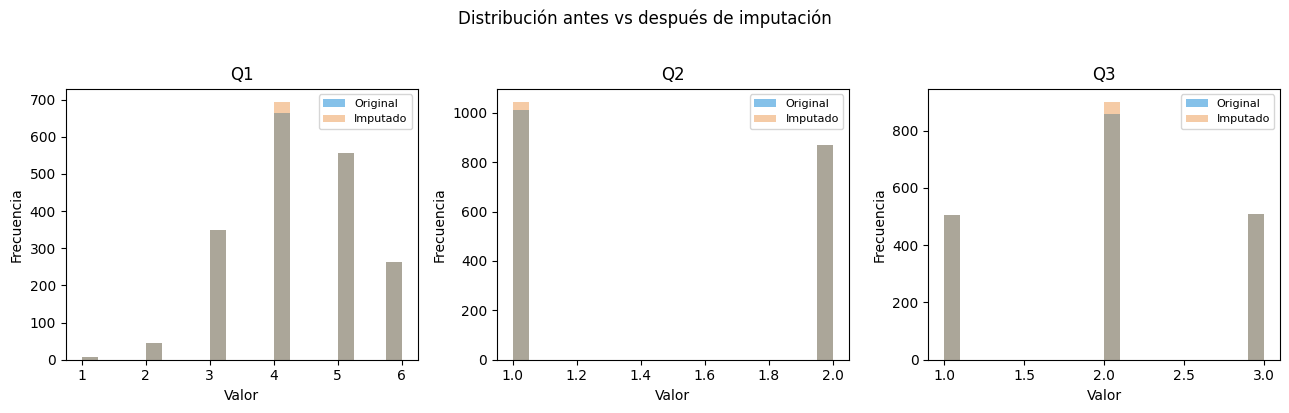

Figura guardada: 06_verificacion_imputacion.png


In [7]:
vars_verificar = ['Q1', 'Q2', 'Q3']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, vars_verificar):
    ax.hist(df[col].dropna(),  bins=20, alpha=0.6,
            color='#3498db', label='Original')
    ax.hist(X[col],            bins=20, alpha=0.4,
            color='#e67e22', label='Imputado')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución antes vs después de imputación', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/06_verificacion_imputacion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: 06_verificacion_imputacion.png")

## 8. Split train/test estratificado
Antes del split eliminamos las filas donde alguno de los targets es NaN:

- `y_B` tiene 9 NaN — no podemos estratificar con valores faltantes
- `y_A` tiene 177 NaN — los manejamos por tarea de forma independiente

Estrategia: usamos el índice limpio de `y_B` para el split estratificado,
y dentro de cada tarea filtramos adicionalmente los NaN de `y_A`.

In [9]:
# Eliminar filas donde y_B es NaN (9 filas)
idx_validos = y_B.dropna().index
X_clean   = X.loc[idx_validos]
y_A_clean = y_A.loc[idx_validos]
y_B_clean = y_B.loc[idx_validos]

print(f"Filas tras eliminar NaN en y_B : {len(X_clean)}")
print(f"NaN en y_B_clean               : {y_B_clean.isna().sum()}")
print(f"NaN en y_A_clean               : {y_A_clean.isna().sum()}")

# Split estratificado por y_B (clase minoritaria)
X_train, X_test, y_A_train, y_A_test, y_B_train, y_B_test = train_test_split(
    X_clean, y_A_clean, y_B_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_B_clean
)

print(f"\nTrain : {X_train.shape[0]} filas")
print(f"Test  : {X_test.shape[0]} filas")

print(f"\nBalance Riesgo_SM en train:")
print(f"  Clase 0 : {(y_B_train == 0).sum()}")
print(f"  Clase 1 : {(y_B_train == 1).sum()}")

print(f"\nBalance Riesgo_SM en test:")
print(f"  Clase 0 : {(y_B_test == 0).sum()}")
print(f"  Clase 1 : {(y_B_test == 1).sum()}")

Filas tras eliminar NaN en y_B : 1906
NaN en y_B_clean               : 0
NaN en y_A_clean               : 177

Train : 1524 filas
Test  : 382 filas

Balance Riesgo_SM en train:
  Clase 0 : 1320
  Clase 1 : 204

Balance Riesgo_SM en test:
  Clase 0 : 331
  Clase 1 : 51


## 9. Aplicar RobustScaler
Ajustamos el scaler **únicamente sobre `X_train`** y lo aplicamos a ambos
conjuntos. Esta regla es crítica: si ajustáramos sobre todo el dataset,
el modelo "vería" información del test durante el entrenamiento (*leakage*
de preprocesamiento).

Guardamos el scaler entrenado en `models/` para reutilizarlo en las
fases de modelado sin necesidad de reajustar.

In [10]:
import joblib
import os

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features_final,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features_final,
    index=X_test.index
)

# Guardar scaler entrenado
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/robust_scaler.pkl')

print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"\nScaler guardado en: models/robust_scaler.pkl")

print(f"\nEstadísticas post-escalado en train (primeras 4 features):")
print(X_train_scaled[features_final[:4]].describe().round(3))

X_train_scaled : (1524, 50)
X_test_scaled  : (382, 50)

Scaler guardado en: models/robust_scaler.pkl

Estadísticas post-escalado en train (primeras 4 features):
             Q1        Q2        Q3       Q18
count  1524.000  1524.000  1524.000  1524.000
mean      0.326     0.457     0.004     1.111
std       1.023     0.498     0.366     2.375
min      -3.000     0.000    -0.500     0.000
25%       0.000     0.000    -0.500     0.000
50%       0.000     0.000     0.000     0.000
75%       1.000     1.000     0.500     0.000
max       2.000     1.000     0.500     7.000


## 10. Guardado de artefactos
Exportamos todas las matrices a `data/processed/` para que las Fases 4
(Regresión) y 5 (Clasificación) las carguen directamente sin repetir
el preprocesamiento.

| Archivo | Descripción |
|---|---|
| `X_train_scaled.csv` | Features de entrenamiento escaladas |
| `X_test_scaled.csv` | Features de prueba escaladas |
| `y_A_train.csv` | Target IMC — entrenamiento |
| `y_A_test.csv` | Target IMC — prueba |
| `y_B_train.csv` | Target Riesgo_SM — entrenamiento |
| `y_B_test.csv` | Target Riesgo_SM — prueba |
| `features_final.txt` | Lista de features seleccionadas |

In [11]:
ruta = '../data/processed/'

X_train_scaled.to_csv(f'{ruta}X_train_scaled.csv', index=True)
X_test_scaled.to_csv(f'{ruta}X_test_scaled.csv',  index=True)

y_A_train.to_csv(f'{ruta}y_A_train.csv', index=True, header=True)
y_A_test.to_csv(f'{ruta}y_A_test.csv',  index=True, header=True)

y_B_train.to_csv(f'{ruta}y_B_train.csv', index=True, header=True)
y_B_test.to_csv(f'{ruta}y_B_test.csv',  index=True, header=True)

# Guardar lista de features para referencia en fases siguientes
with open(f'{ruta}features_final.txt', 'w') as f:
    for feat in features_final:
        f.write(feat + '\n')

print("Artefactos guardados en data/processed/:")
archivos = [
    'X_train_scaled.csv', 'X_test_scaled.csv',
    'y_A_train.csv', 'y_A_test.csv',
    'y_B_train.csv', 'y_B_test.csv',
    'features_final.txt'
]
for arch in archivos:
    ruta_completa = f'{ruta}{arch}'
    tam = os.path.getsize(ruta_completa) / 1024
    print(f"  ✓ {arch:<25} {tam:.1f} KB")

Artefactos guardados en data/processed/:
  ✓ X_train_scaled.csv        343.0 KB
  ✓ X_test_scaled.csv         86.4 KB
  ✓ y_A_train.csv             31.6 KB
  ✓ y_A_test.csv              8.0 KB
  ✓ y_B_train.csv             12.5 KB
  ✓ y_B_test.csv              3.2 KB
  ✓ features_final.txt        0.2 KB
